# Версия “SkyLenta: Эксперимент и калькулятор”

# Описание дипломной работы

Вы работаете аналитиком данных в крупном ритейлере *SkyLenta*, который присутствует во многих российских города 

Вы работаете в отделе продуктовой аналитики, и ваша текущая задача - проанализировать АБ-Тест, проведенный во всех городах.

In [3]:
#### Import's
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import seaborn as sns

In [4]:
### Импорт таблиц

file = pd.ExcelFile('Новый диплом датасет.xlsx')
data_frames = {sheet: file.parse(sheet) for sheet in file.sheet_names}

### Смотрим таблицы каждого листа

data = data_frames['Данные']
clients = data_frames['Clients']
region_dict = data_frames['Region_dict']
########

In [5]:
### Убираем все пустые значания (нулловые)
### Так как null - это пустые колонки, это может быть либо сбой в системе, либо вообще не иметь данных. Работа с такими данными может привессти к некорректности  
data[~data['id_client'].isnull()]
data[~data['amt_payment'].isnull()]
data_n_null = data[~data['dtime_pay'].isnull()]
###
data_n_null
###################

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,100242,191056.0,4151.0,2022-08-01 02:42:54.992
2,100249,200049.0,5688.0,2022-08-24 12:45:12.744
3,100258,206161.0,4330.0,2022-12-09 15:13:26.437
4,100267,190945.0,5488.0,2022-08-03 02:07:31.468
...,...,...,...,...
37983,297572,195257.0,2191.0,2022-08-21 18:31:51.585
37985,297593,179230.0,5755.0,2022-09-05 03:29:07.726
37986,297595,192530.0,4448.0,2022-09-27 23:50:05.734
37987,297601,183888.0,1746.0,2022-10-13 14:23:03.073


In [6]:
## Убрал нуллы в clients - столбец dtime_ad
clients_n_null = clients[~clients['dtime_ad'].isnull()]
###
clients_n_null 

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015
5,254313,2022-06-19 22:18:01.770,1,453
...,...,...,...,...
55600,193038,2022-07-09 00:31:25.196,0,1015
55601,244069,2022-08-08 00:12:31.319,1,991
55602,189084,2022-06-29 04:34:42.610,1,439
55603,182758,2022-06-13 11:28:37.856,1,573


In [7]:
#Исследовал количество торговых точек в каждом городе
cnt_point = region_dict.groupby('city').agg(cnt_point = ('id_trading_point','count')).reset_index()

####-####
cnt_point

,city,cnt_point
0,Великий Новгород,1
1,Владимир,1
2,Волгоград,1
3,Дмитров,1
4,Казань,6
5,Краснодар,4
6,Красноярск,5
7,Москва,11
8,Мурманск,2
9,Нижний Новгород,1


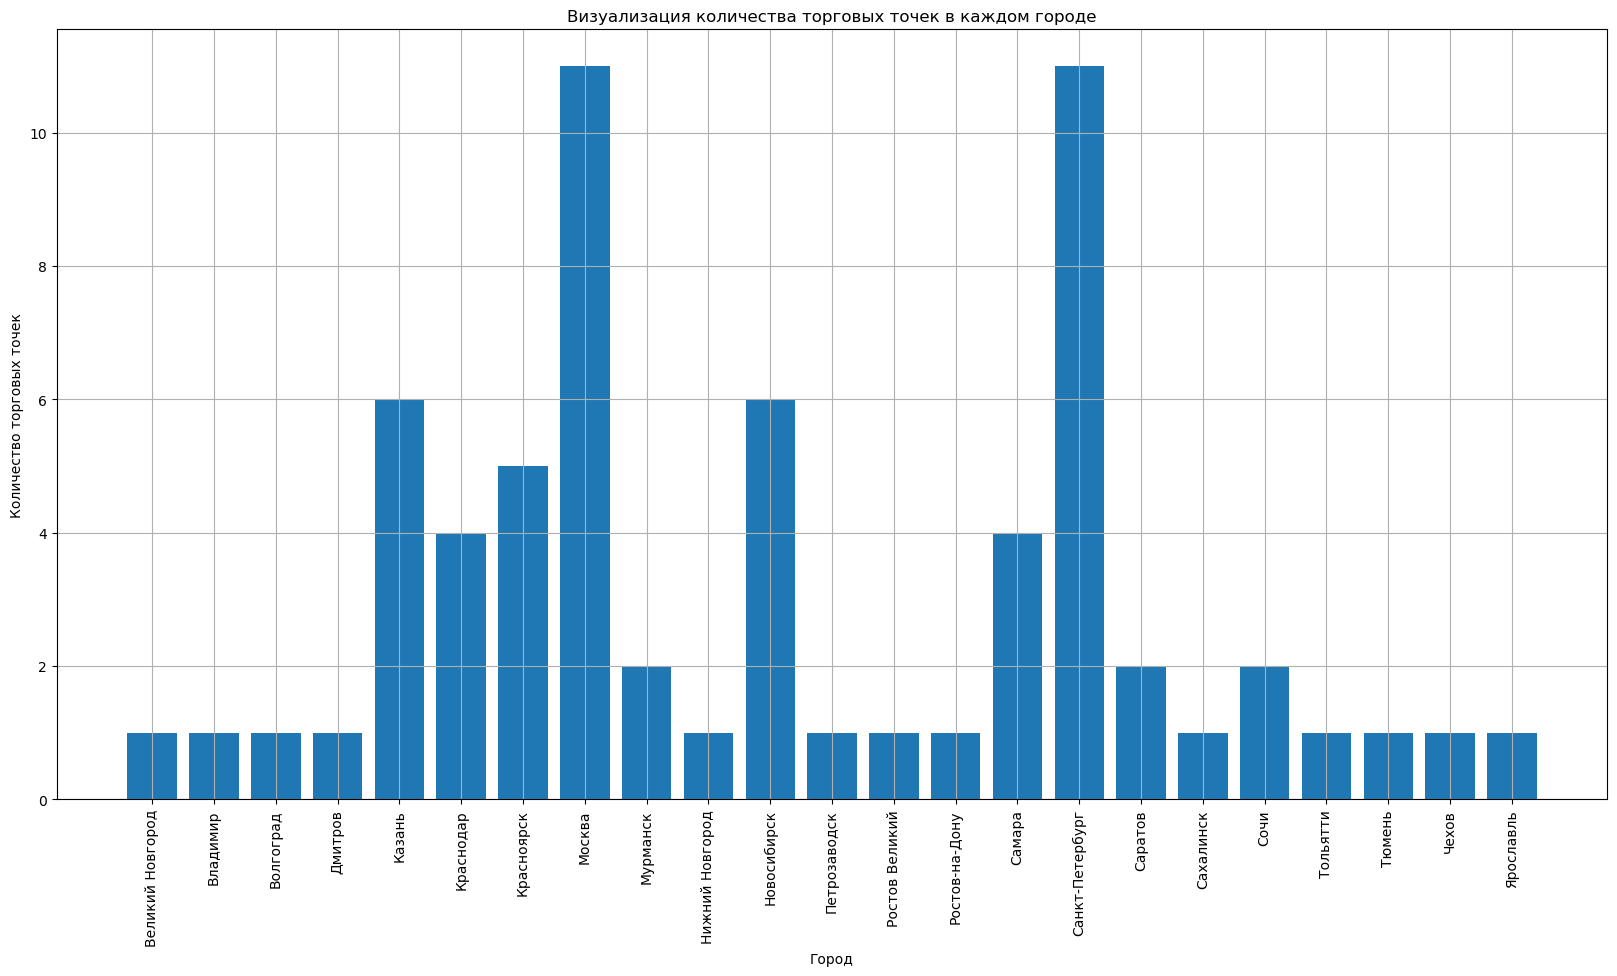

In [8]:
### Визуализация
x = cnt_point['city']
y = cnt_point['cnt_point']


plt.figure(figsize=(20,10))
plt.bar(x, y)
plt.xticks(rotation=90)
plt.xlabel('Город')
plt.ylabel('Количество торговых точек')
plt.title('Визуализация количества торговых точек в каждом городе')
plt.grid()
plt.show()

In [9]:
#### $   №2------------------------------


In [10]:
amt_pay_client = data_n_null.groupby('id_client').agg({'amt_payment':'sum'}).reset_index()
amt_pay_client

,id_client,amt_payment
0,178561.0,3052.0
1,178562.0,2439.0
2,178563.0,768.0
3,178565.0,958.0
4,178566.0,5474.0
...,...,...
28378,209630.0,6927.0
28379,209631.0,2090.0
28380,209632.0,2775.0
28381,209633.0,1673.0


In [11]:
Join_amt_client = amt_pay_client.merge(clients_n_null, how = 'right', left_on=['id_client'], right_on=
['id_client'])
Join_amt_client

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212
1,226069.0,NaN,2022-07-11 16:28:38.511,1,54
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991
3,322530.0,NaN,2022-07-08 08:56:08.714,0,1015
4,254313.0,NaN,2022-06-19 22:18:01.770,1,453
...,...,...,...,...,...
55351,193038.0,5846.0,2022-07-09 00:31:25.196,0,1015
55352,244069.0,NaN,2022-08-08 00:12:31.319,1,991
55353,189084.0,7146.0,2022-06-29 04:34:42.610,1,439
55354,182758.0,13720.0,2022-06-13 11:28:37.856,1,573


In [12]:
Join_amt_client['amt_payment'] = Join_amt_client['amt_payment'].fillna(0)
Join_amt_client

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212
1,226069.0,0.0,2022-07-11 16:28:38.511,1,54
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991
3,322530.0,0.0,2022-07-08 08:56:08.714,0,1015
4,254313.0,0.0,2022-06-19 22:18:01.770,1,453
...,...,...,...,...,...
55351,193038.0,5846.0,2022-07-09 00:31:25.196,0,1015
55352,244069.0,0.0,2022-08-08 00:12:31.319,1,991
55353,189084.0,7146.0,2022-06-29 04:34:42.610,1,439
55354,182758.0,13720.0,2022-06-13 11:28:37.856,1,573


In [13]:
Join_point_region = Join_amt_client.merge(region_dict, how = 'inner', left_on=['id_trading_point'], right_on=
['id_trading_point'])
Join_point_region

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск
1,223863.0,0.0,2022-08-20 21:56:54.325,0,212,Красноярск
2,201715.0,4171.0,2022-07-30 19:07:49.264,1,212,Красноярск
3,292010.0,0.0,2022-07-26 20:37:16.885,1,212,Красноярск
4,190438.0,6026.0,2022-07-02 12:53:04.753,1,212,Красноярск
...,...,...,...,...,...,...
55351,321313.0,0.0,2022-06-17 15:42:47.009,1,1002,Москва
55352,200856.0,6696.0,2022-07-28 14:51:08.149,1,1002,Москва
55353,198305.0,3901.0,2022-07-22 06:24:33.232,0,1002,Москва
55354,201820.0,0.0,2022-07-31 01:25:03.638,0,1002,Москва


In [14]:
Join_point_region['is_flag_pay'] = np.where(Join_point_region['amt_payment'] > 0 , 1,0)
flag_Join_2 = Join_point_region
flag_Join_2
######
# 1 - заплатил
# 0 - не заплатил

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,is_flag_pay
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,223863.0,0.0,2022-08-20 21:56:54.325,0,212,Красноярск,0
2,201715.0,4171.0,2022-07-30 19:07:49.264,1,212,Красноярск,1
3,292010.0,0.0,2022-07-26 20:37:16.885,1,212,Красноярск,0
4,190438.0,6026.0,2022-07-02 12:53:04.753,1,212,Красноярск,1
...,...,...,...,...,...,...,...
55351,321313.0,0.0,2022-06-17 15:42:47.009,1,1002,Москва,0
55352,200856.0,6696.0,2022-07-28 14:51:08.149,1,1002,Москва,1
55353,198305.0,3901.0,2022-07-22 06:24:33.232,0,1002,Москва,1
55354,201820.0,0.0,2022-07-31 01:25:03.638,0,1002,Москва,0


In [15]:
##### Создания функций
def test_calc(r1, r2,alpha = .05):
    s, p = ttest_ind(r1, r2)
    print("Среднее первого ряда = ", r1.mean())
    print("Среднее второго ряда = ", r2.mean())
    print()
    print("Значение стат.критерия = ",s)
    print("Значение p_value = ",p)
    if p > alpha:
        print('Средние выборок равны')
    else:
        print('Средние выборок не равны')
    return s,p

In [16]:
def mann_whitney_func(r1, r2,alpha = .05):

    mw_stat, p_value = mannwhitneyu(x=r1, y=r2)
    mw_stat, p_value = mannwhitneyu(x=r2, y=r1)


    if p_value < alpha:
        print('Распределения не равны')
    else:
        print('Распределения равны')

In [17]:
flag_Join_2 ## Проверка

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,is_flag_pay
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,223863.0,0.0,2022-08-20 21:56:54.325,0,212,Красноярск,0
2,201715.0,4171.0,2022-07-30 19:07:49.264,1,212,Красноярск,1
3,292010.0,0.0,2022-07-26 20:37:16.885,1,212,Красноярск,0
4,190438.0,6026.0,2022-07-02 12:53:04.753,1,212,Красноярск,1
...,...,...,...,...,...,...,...
55351,321313.0,0.0,2022-06-17 15:42:47.009,1,1002,Москва,0
55352,200856.0,6696.0,2022-07-28 14:51:08.149,1,1002,Москва,1
55353,198305.0,3901.0,2022-07-22 06:24:33.232,0,1002,Москва,1
55354,201820.0,0.0,2022-07-31 01:25:03.638,0,1002,Москва,0


In [18]:
## -- 4
##  не было заплачено ни одного рубля
list_0 = []

for i in flag_Join_2['id_trading_point'].unique():
    
    sum_1 = flag_Join_2[(flag_Join_2['id_trading_point']==i) & (flag_Join_2['nflag_test']==0)]['amt_payment'].sum()
    sum_2 = flag_Join_2[(flag_Join_2['id_trading_point']==i) & (flag_Join_2['nflag_test']==1)]['amt_payment'].sum()
    
    if (sum_1 == 0) | (sum_2 == 0):
        list_0.append(i)

list_0

[1015, 866, 1099, 739, 46, 228, 26, 603, 810, 800, 7, 23, 4, 1, 13]

In [19]:
##  пустует или контрольная, или тестовая группа.
list_control_test = []

for i in flag_Join_2['id_trading_point'].unique():
    
    count_1 = flag_Join_2[(flag_Join_2['id_trading_point']==i) & (flag_Join_2['nflag_test']==0)]['amt_payment'].count()
    count_2 = flag_Join_2[(flag_Join_2['id_trading_point']==i) & (flag_Join_2['nflag_test']==1)]['amt_payment'].count()
    
    if (count_1 == 0) | (count_2 == 0):
        list_control_test.append(i)

list_control_test

[1015, 866, 1099, 739, 228, 603, 810, 800]

In [20]:
## # * 5 *

filtr_point = flag_Join_2[~flag_Join_2['id_trading_point'].isin(list_0 + list_control_test)]
filtr_point

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,is_flag_pay
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,223863.0,0.0,2022-08-20 21:56:54.325,0,212,Красноярск,0
2,201715.0,4171.0,2022-07-30 19:07:49.264,1,212,Красноярск,1
3,292010.0,0.0,2022-07-26 20:37:16.885,1,212,Красноярск,0
4,190438.0,6026.0,2022-07-02 12:53:04.753,1,212,Красноярск,1
...,...,...,...,...,...,...,...
55351,321313.0,0.0,2022-06-17 15:42:47.009,1,1002,Москва,0
55352,200856.0,6696.0,2022-07-28 14:51:08.149,1,1002,Москва,1
55353,198305.0,3901.0,2022-07-22 06:24:33.232,0,1002,Москва,1
55354,201820.0,0.0,2022-07-31 01:25:03.638,0,1002,Москва,0


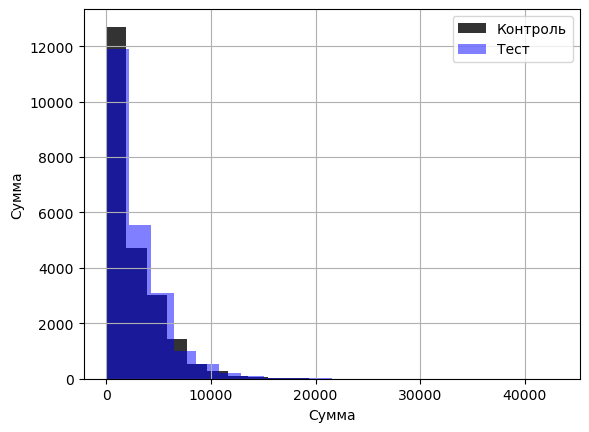

In [21]:
control = filtr_point[filtr_point['nflag_test'] == 0]
test = filtr_point[filtr_point['nflag_test'] == 1]

plt.hist(control['amt_payment'], bins= 20, alpha= 0.8, color= 'k', label= 'Контроль')
plt.hist(test['amt_payment'], bins= 20, alpha= 0.5, color= 'blue', label= 'Тест')

plt.grid()

plt.xlabel('Сумма')
plt.ylabel('Сумма')
plt.legend()


plt.show()

In [22]:
filtr_point

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,is_flag_pay
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,223863.0,0.0,2022-08-20 21:56:54.325,0,212,Красноярск,0
2,201715.0,4171.0,2022-07-30 19:07:49.264,1,212,Красноярск,1
3,292010.0,0.0,2022-07-26 20:37:16.885,1,212,Красноярск,0
4,190438.0,6026.0,2022-07-02 12:53:04.753,1,212,Красноярск,1
...,...,...,...,...,...,...,...
55351,321313.0,0.0,2022-06-17 15:42:47.009,1,1002,Москва,0
55352,200856.0,6696.0,2022-07-28 14:51:08.149,1,1002,Москва,1
55353,198305.0,3901.0,2022-07-22 06:24:33.232,0,1002,Москва,1
55354,201820.0,0.0,2022-07-31 01:25:03.638,0,1002,Москва,0


In [23]:
test_calc(filtr_point[filtr_point['nflag_test'] == 0]['amt_payment'],filtr_point[filtr_point['nflag_test'] == 1]['amt_payment'])

Среднее первого ряда =  2189.1884317754557
Среднее второго ряда =  2452.2773446201827

Значение стат.критерия =  -9.456798235171377
Значение p_value =  3.3214645838934018e-21
Средние выборок не равны


(-9.456798235171377, 3.3214645838934018e-21)

In [24]:
test_calc(filtr_point[filtr_point['is_flag_pay'] == 0]['amt_payment'],filtr_point[filtr_point['is_flag_pay'] == 1]['amt_payment'])

Среднее первого ряда =  0.0
Среднее второго ряда =  4449.298285714286

Значение стат.критерия =  -241.30488443904585
Значение p_value =  0.0
Средние выборок не равны


(-241.30488443904585, 0.0)

In [25]:
mann_whitney_func(filtr_point[filtr_point['is_flag_pay'] == 0]['amt_payment'],filtr_point[filtr_point['is_flag_pay'] == 1]['amt_payment'])

Распределения не равны


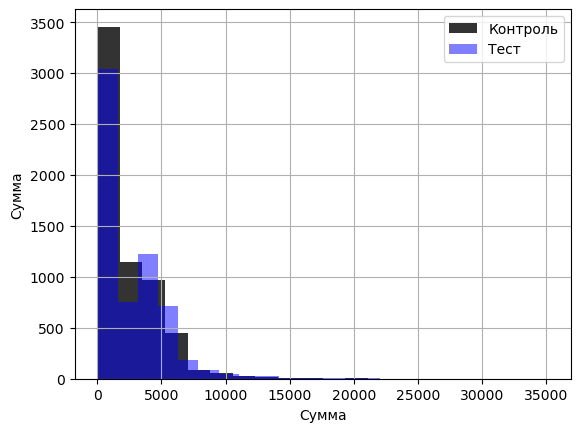

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,is_flag_pay
6303,195818.0,4021.0,2022-07-16 01:30:59.088,1,2652,Москва,1
6304,274394.0,0.0,2022-06-25 00:46:07.492,1,2652,Москва,0
6305,205352.0,0.0,2022-08-08 20:59:32.806,0,2652,Москва,0
6306,185585.0,0.0,2022-06-20 12:40:52.026,0,2652,Москва,0
6307,201098.0,0.0,2022-07-29 05:27:45.057,0,2652,Москва,0
...,...,...,...,...,...,...,...
55351,321313.0,0.0,2022-06-17 15:42:47.009,1,1002,Москва,0
55352,200856.0,6696.0,2022-07-28 14:51:08.149,1,1002,Москва,1
55353,198305.0,3901.0,2022-07-22 06:24:33.232,0,1002,Москва,1
55354,201820.0,0.0,2022-07-31 01:25:03.638,0,1002,Москва,0


In [26]:
### №6

msk = filtr_point[filtr_point['city'] =='Москва']
msk_control = msk[msk['nflag_test'] == 0]
msk_test = msk[msk['nflag_test'] == 1]

plt.hist(msk_control['amt_payment'], bins= 20, alpha= 0.8, color= 'k', label= 'Контроль')
plt.hist(msk_test['amt_payment'], bins= 20, alpha= 0.5, color= 'blue', label= 'Тест')

plt.grid()

plt.xlabel('Сумма')
plt.ylabel('Сумма')
plt.legend()


plt.show()

msk

In [27]:
test_calc(msk[msk['nflag_test'] == 0]['amt_payment'],msk[msk['nflag_test'] == 1]['amt_payment'])

Среднее первого ряда =  1986.18059125964
Среднее второго ряда =  2367.9590805347243

Значение стат.критерия =  -7.676511027843395
Значение p_value =  1.757549439555765e-14
Средние выборок не равны


(-7.676511027843395, 1.757549439555765e-14)

In [28]:
test_calc(msk[msk['is_flag_pay'] == 0]['amt_payment'],msk[msk['is_flag_pay'] == 1]['amt_payment'])

Среднее первого ряда =  0.0
Среднее второго ряда =  4220.224297598493

Значение стат.критерия =  -130.4851130426922
Значение p_value =  0.0
Средние выборок не равны


(-130.4851130426922, 0.0)

In [29]:
mann_whitney_func(msk[msk['is_flag_pay'] == 0]['amt_payment'],msk[msk['is_flag_pay'] == 1]['amt_payment'])

Распределения не равны


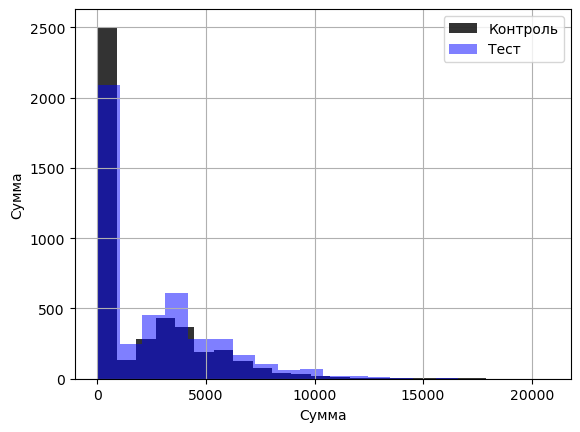

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,is_flag_pay
4188,254313.0,0.0,2022-06-19 22:18:01.770,1,453,Санкт-Петербург,0
4189,200225.0,4372.0,2022-07-27 00:18:47.370,0,453,Санкт-Петербург,1
4190,205357.0,2818.0,2022-08-08 21:22:23.684,0,453,Санкт-Петербург,1
4191,267794.0,0.0,2022-08-01 07:07:55.411,0,453,Санкт-Петербург,0
4192,200093.0,5676.0,2022-07-26 16:05:12.765,0,453,Санкт-Петербург,1
...,...,...,...,...,...,...,...
53517,209321.0,2850.0,2022-08-18 19:00:11.130,0,891,Санкт-Петербург,1
53518,184426.0,12622.0,2022-06-17 15:54:41.802,1,891,Санкт-Петербург,1
53519,180957.0,2355.0,2022-06-09 01:11:41.241,1,891,Санкт-Петербург,1
53520,191999.0,3571.0,2022-07-06 11:12:37.976,0,891,Санкт-Петербург,1


In [30]:
spb = filtr_point[filtr_point['city'] =='Санкт-Петербург']

spb_control = spb[spb['nflag_test'] == 0]
spb_test = spb[spb['nflag_test'] == 1]

plt.hist(spb_control['amt_payment'], bins= 20, alpha= 0.8, color= 'k', label= 'Контроль')
plt.hist(spb_test['amt_payment'], bins= 20, alpha= 0.5, color= 'blue', label= 'Тест')

plt.grid()

plt.xlabel('Сумма')
plt.ylabel('Сумма')
plt.legend()


plt.show()

spb

In [31]:
test_calc(spb[spb['nflag_test'] == 0]['amt_payment'],spb[spb['nflag_test'] == 1]['amt_payment'])

Среднее первого ряда =  1913.5586377988272
Среднее второго ряда =  2427.462542182227

Значение стат.критерия =  -8.759635784179547
Значение p_value =  2.3198088937974163e-18
Средние выборок не равны


(-8.759635784179547, 2.3198088937974163e-18)

In [32]:
test_calc(spb[spb['is_flag_pay'] == 0]['amt_payment'],spb[spb['is_flag_pay'] == 1]['amt_payment'])

Среднее первого ряда =  0.0
Среднее второго ряда =  4360.81221719457

Значение стат.критерия =  -119.60146518474866
Значение p_value =  0.0
Средние выборок не равны


(-119.60146518474866, 0.0)

In [33]:
mann_whitney_func(spb[spb['is_flag_pay'] == 0]['amt_payment'],spb[spb['is_flag_pay'] == 1]['amt_payment'])

Распределения не равны


Красноярск


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


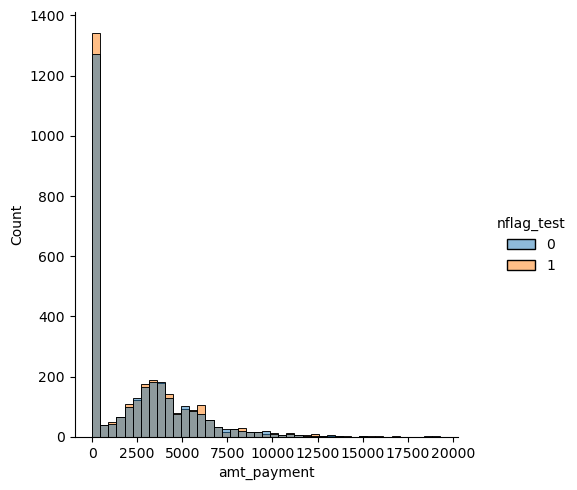

          Сравниваем средние платежи

Среднее первого ряда =  2428.7775862068966
Среднее второго ряда =  2437.4958840961476

Значение стат.критерия =  -0.12000608689929208
Значение p_value =  0.9044823881233125
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4348.62432269717

Значение стат.критерия =  -93.46677604397276
Значение p_value =  0.0
Средние выборок не равны


Распределения не равны
Мурманск


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


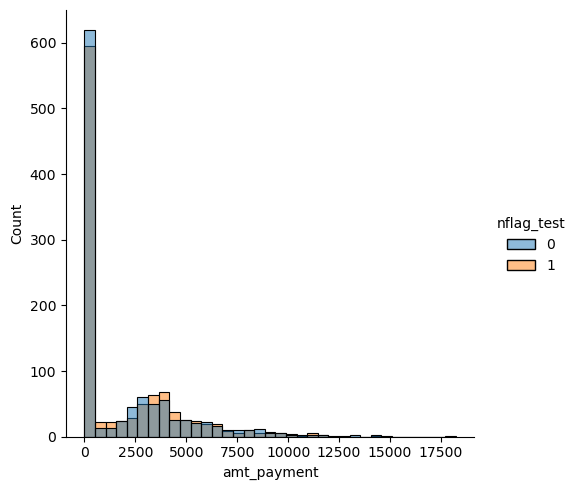

          Сравниваем средние платежи

Среднее первого ряда =  1857.2197183098592
Среднее второго ряда =  1865.2710900473933

Значение стат.критерия =  -0.06902498862889384
Значение p_value =  0.9449762446327565
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4350.385887541345

Значение стат.критерия =  -61.77512715899208
Значение p_value =  0.0
Средние выборок не равны


Распределения не равны
Казань


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


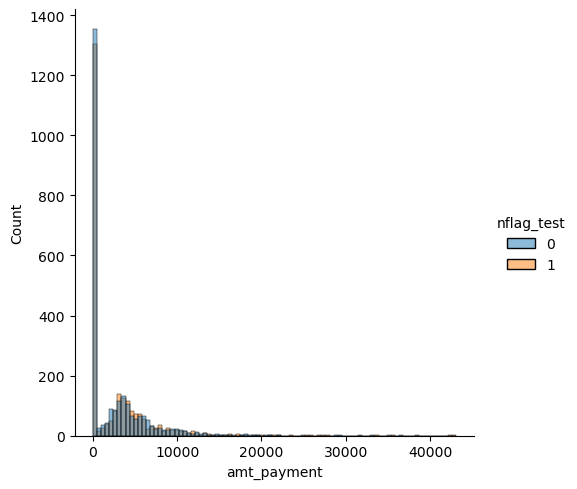

          Сравниваем средние платежи

Среднее первого ряда =  2610.688397361273
Среднее второго ряда =  2731.9132

Значение стат.критерия =  -1.0655273408818378
Значение p_value =  0.286688049247618
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  5599.969847170591

Значение стат.критерия =  -67.94946188568971
Значение p_value =  0.0
Средние выборок не равны


Распределения не равны
Саратов


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


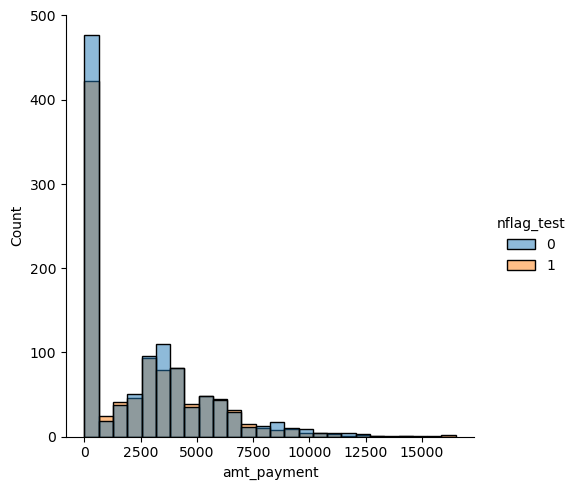

          Сравниваем средние платежи

Среднее первого ряда =  2541.6456266907126
Среднее второго ряда =  2528.7887462981244

Значение стат.критерия =  0.10516947629572568
Значение p_value =  0.9162512798549167
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4363.623682076237

Значение стат.критерия =  -54.82366454874657
Значение p_value =  0.0
Средние выборок не равны


Распределения не равны
Тольятти


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


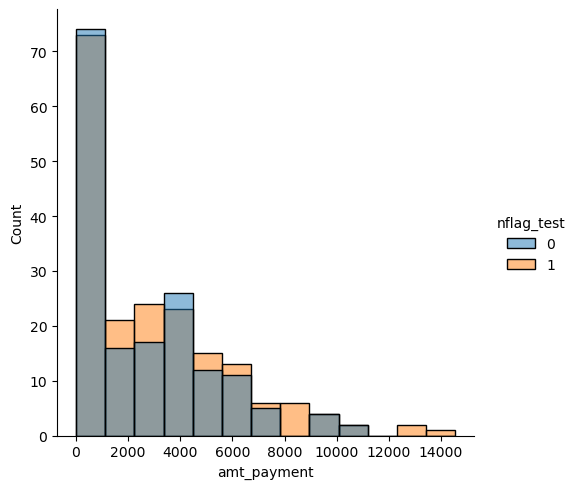

          Сравниваем средние платежи

Среднее первого ряда =  2439.4610778443116
Среднее второго ряда =  2902.4105263157894

Значение стат.критерия =  -1.5045563456740754
Значение p_value =  0.1333273246710206
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4378.301369863014

Значение стат.критерия =  -20.405587395596417
Значение p_value =  8.589607753012094e-62
Средние выборок не равны


Распределения не равны
Тюмень


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


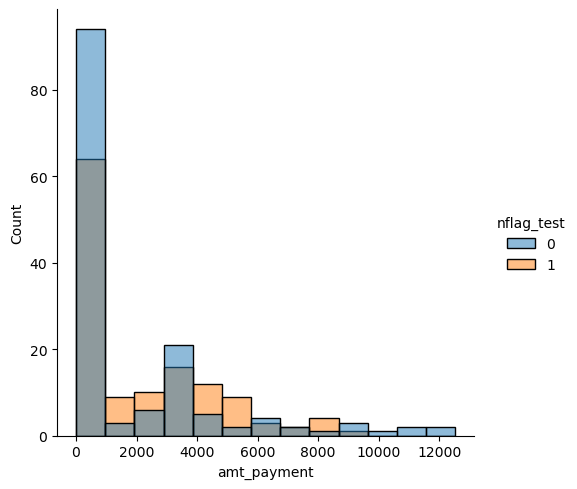

          Сравниваем средние платежи

Среднее первого ряда =  1743.376712328767
Среднее второго ряда =  2043.823076923077

Значение стат.критерия =  -0.9264590634677944
Значение p_value =  0.3550227648604757
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4229.512195121952

Значение стат.критерия =  -20.859607878269745
Значение p_value =  1.624386988833194e-58
Средние выборок не равны


Распределения не равны
Волгоград


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


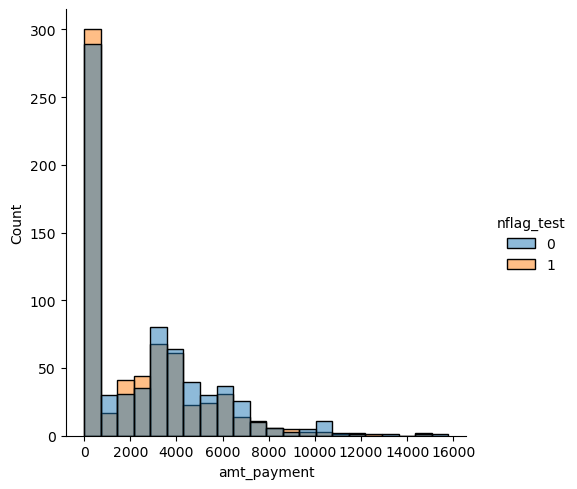

          Сравниваем средние платежи

Среднее первого ряда =  2601.7610241820767
Среднее второго ряда =  2288.8706240487063

Значение стат.критерия =  2.0892718943323443
Значение p_value =  0.03686899928098654
Средние выборок не равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4261.925831202046

Значение стат.критерия =  -43.4611864028733
Значение p_value =  2.550700810255085e-259
Средние выборок не равны


Распределения не равны
Сочи


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


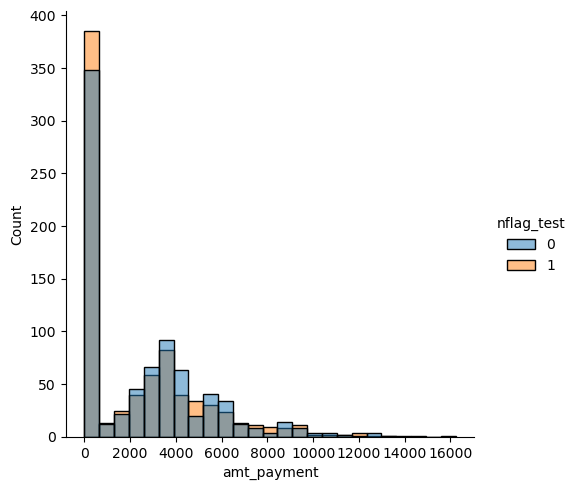

          Сравниваем средние платежи

Среднее первого ряда =  2523.081885856079
Среднее второго ряда =  2305.8304020100504

Значение стат.критерия =  1.5432162776667724
Значение p_value =  0.12297605685687812
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4391.651532349602

Значение стат.критерия =  -49.12127624412539
Значение p_value =  8.7e-322
Средние выборок не равны


Распределения не равны
Владимир


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


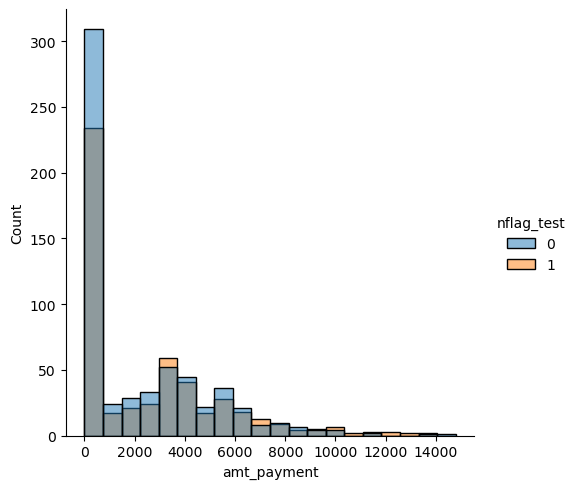

          Сравниваем средние платежи

Среднее первого ряда =  2108.6101973684213
Среднее второго ряда =  2547.2200392927307

Значение стат.критерия =  -2.5769554932923184
Значение p_value =  0.010095112170351712
Средние выборок не равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4422.933104631218

Значение стат.критерия =  -41.38049763595606
Значение p_value =  1.5807043322530109e-227
Средние выборок не равны


Распределения не равны
Самара


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


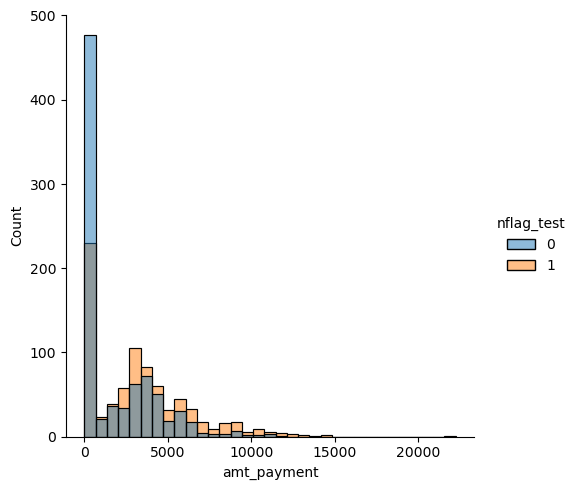

          Сравниваем средние платежи

Среднее первого ряда =  1718.4172576832152
Среднее второго ряда =  3262.78927680798

Значение стат.критерия =  -11.54083248253458
Значение p_value =  1.1014020778472052e-29
Средние выборок не равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4298.350580781415

Значение стат.критерия =  -46.46217814246114
Значение p_value =  8.53834496474073e-302
Средние выборок не равны


Распределения не равны
Краснодар


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


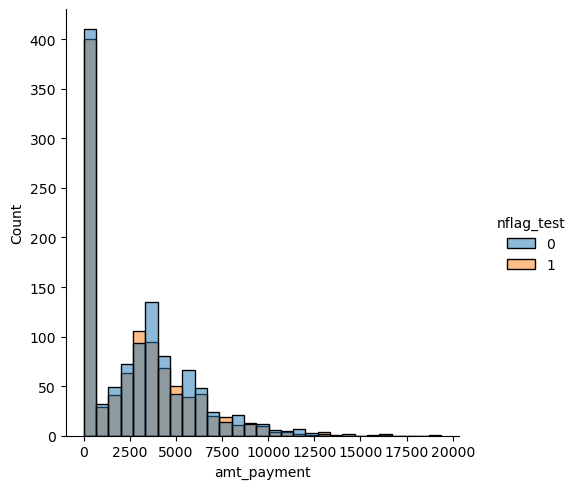

          Сравниваем средние платежи

Среднее первого ряда =  2912.4310798946444
Среднее второго ряда =  2696.8046875

Значение стат.критерия =  1.718766529966594
Значение p_value =  0.085800112916198
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4427.375819373634

Значение стат.критерия =  -49.886995155304135
Значение p_value =  0.0
Средние выборок не равны


Распределения не равны
Сахалинск


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


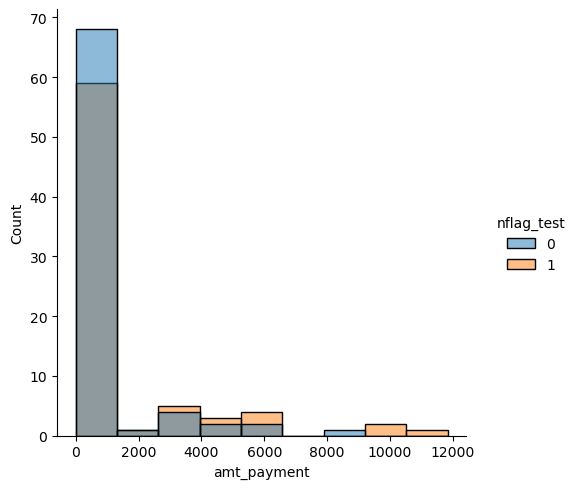

          Сравниваем средние платежи

Среднее первого ряда =  600.1538461538462
Среднее второго ряда =  1171.4533333333334

Значение стат.критерия =  -1.6270604929283117
Значение p_value =  0.10580921254927302
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4987.814814814815

Значение стат.критерия =  -22.09447325517156
Значение p_value =  3.616785003704224e-49
Средние выборок не равны


Распределения не равны
Дмитров


C:\Users\zhele\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


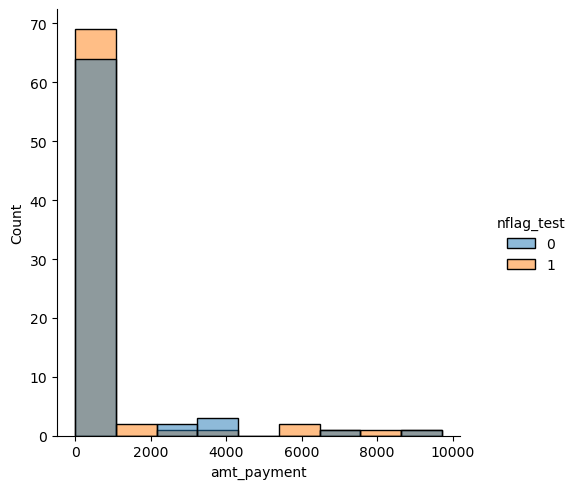

          Сравниваем средние платежи

Среднее первого ряда =  483.4507042253521
Среднее второго ряда =  579.3333333333334

Значение стат.критерия =  -0.3310524347645207
Значение p_value =  0.7410763125801646
Средние выборок равны

          Cравниваем конверсию в платеж

Среднее первого ряда =  0.0
Среднее второго ряда =  4969.5625

Значение стат.критерия =  -22.12171369867668
Значение p_value =  1.2556197867843278e-48
Средние выборок не равны


Распределения не равны


In [34]:
### Другие города
dd = filtr_point
another_city = filtr_point[~filtr_point['city'].isin(['Москва', 'Санкт-Петербург'])]

for i in another_city['city'].unique():
    print(i)
    all_another_city = dd[dd['city'] == i]
    sns.displot(all_another_city, x = 'amt_payment', hue = 'nflag_test')
    plt.show()

    print((' ')*10 + 'Сравниваем средние платежи'+ '\n')
    test_calc(all_another_city[all_another_city['nflag_test'] == 0]['amt_payment'],all_another_city[all_another_city['nflag_test'] == 1]['amt_payment'])
    print('\n' + (' ')*10 + 'Cравниваем конверсию в платеж'+ '\n')
    test_calc(all_another_city[all_another_city['is_flag_pay'] == 0]['amt_payment'],all_another_city[all_another_city['is_flag_pay'] == 1]['amt_payment'])
    print('\n')
    mann_whitney_func(all_another_city[all_another_city['is_flag_pay'] == 0]['amt_payment'],all_another_city[all_another_city['is_flag_pay'] == 1]['amt_payment'])

In [35]:
df_result_all = pd.DataFrame()

for i in filtr_point['city'].unique():
    city_df = filtr_point[filtr_point['city']==i]
    
    for j in city_df['id_trading_point'].unique():
        point_df_result_all = city_df[city_df['id_trading_point']==j]
        
        count_test = len(point_df_result_all[point_df_result_all['nflag_test'] == 1])
        count_control = len(point_df_result_all[point_df_result_all['nflag_test'] == 0])
        count_all = count_test + count_control
        
        percent_count  = len(point_df_result_all['id_trading_point']) / len(filtr_point['id_trading_point']) * 100
        
        avg_payment_test = point_df_result_all[point_df_result_all['nflag_test'] == 1]['amt_payment'].mean()
        avg_payment_control = point_df_result_all[point_df_result_all['nflag_test'] == 0]['amt_payment'].mean()
        diff = avg_payment_test - avg_payment_control

        sigma_test = point_df_result_all[point_df_result_all['nflag_test']==1]['amt_payment'].std()
        sigma_control = point_df_result_all[point_df_result_all['nflag_test']==0]['amt_payment'].std()

        s_t,p_v  = test_calc(point_df_result_all[point_df_result_all['nflag_test']==1]['amt_payment'], point_df_result_all[point_df_result_all['nflag_test']==0]['amt_payment'])
        ttest = s_t
        pvalue_ttest = p_v

        df_result_all = df_result_all._append({  'city':i, 'id_trading_point':j
                                        , 'count_test':count_test, 'count_control':count_control, 'count_all':count_all, 'percent_count':percent_count
                                        , 'avg_payment_test':avg_payment_test, 'avg_payment_control':avg_payment_control, 'diff':diff  
                                        , 'sigma_test':sigma_test, 'sigma_control':sigma_control
                                        , 'ttest':ttest, 'pvalue_ttest':pvalue_ttest\
                                     }, ignore_index=True)

df_result_all['flag_diff'] = np.where((df_result_all['diff'] > 0) & (df_result_all['pvalue_ttest'] < .05),'Positive outcome',
                                      np.where((df_result_all['diff'] < 0) & (df_result_all['pvalue_ttest'] < .05), 'Negative outcome', 'Neutral outcome'))

Среднее первого ряда =  2144.317032040472
Среднее второго ряда =  2222.0521739130436

Значение стат.критерия =  -0.4835853855099397
Значение p_value =  0.6287709476405416
Средние выборок равны
Среднее первого ряда =  2499.345794392523
Среднее второго ряда =  2185.2147239263804

Значение стат.критерия =  1.8202681201948652
Значение p_value =  0.06901056074583502
Средние выборок равны
Среднее первого ряда =  2927.3411978221416
Среднее второго ряда =  2730.378761061947

Значение стат.критерия =  1.155072918440385
Значение p_value =  0.24830826390447136
Средние выборок равны
Среднее первого ряда =  2404.106153846154
Среднее второго ряда =  2545.73487544484

Значение стат.критерия =  -0.8767403719314057
Значение p_value =  0.3808017001028424
Средние выборок равны
Среднее первого ряда =  2285.75
Среднее второго ряда =  2431.3653032440056

Значение стат.критерия =  -0.9817054668531612
Значение p_value =  0.3264127897793312
Средние выборок равны
Среднее первого ряда =  1702.7140600315956
Средн

In [36]:
df_result_all

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,flag_diff
0,Красноярск,212,593,575,1168,2.577342,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,-0.483585,6.287709e-01,Neutral outcome
1,Красноярск,278,535,489,1024,2.259588,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,1.820268,6.901056e-02,Neutral outcome
2,Красноярск,202,551,565,1116,2.462598,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,1.155073,2.483083e-01,Neutral outcome
3,Красноярск,444,650,562,1212,2.674434,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,-0.876740,3.808017e-01,Neutral outcome
4,Красноярск,277,708,709,1417,3.126793,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,-0.981705,3.264128e-01,Neutral outcome
5,Мурманск,54,633,640,1273,2.809038,1702.714060,1688.512500,14.201560,2565.132440,2628.012490,0.097556,9.223005e-01,Neutral outcome
6,Мурманск,55,422,425,847,1.869015,2109.106635,2111.272941,-2.166306,2790.993385,2804.223188,-0.011268,9.910125e-01,Neutral outcome
7,Казань,991,270,294,564,1.244539,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,2.255258,2.450100e-02,Positive outcome
8,Казань,699,482,494,976,2.153670,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,-0.594254,5.524804e-01,Neutral outcome
9,Казань,477,382,386,768,1.694691,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,-0.891593,3.728909e-01,Neutral outcome


In [37]:
# df_net = pd.DataFrame(df_result_all[df_result_all['flag_diff'] == 'Neutral outcome'])
# df_neg = pd.DataFrame(df_result_all[df_result_all['flag_diff'] == 'Negative outcome'])
# df_pos = pd.DataFrame(df_result_all[df_result_all['flag_diff'] == 'Positive outcome'])

# with pd.ExcelWriter("Дипломная Работа SkyLenta.xlsx", engine="xlsxwriter") as writer:
#     df_net.to_excel (writer, sheet_name='Neutral outcome', index=False)
#     df_neg. to_excel (writer, sheet_name='Negative outcome', index=False)
#     df_pos. to_excel (writer, sheet_name='Positive outcome', index=False)